# 📝 EDA Worksheet — Auto-MPG Dataset
**Student Name:** ___________________________  |  **Date:** _______________

Complete every `# TODO` cell. Run the cells in order.  
Answer the written questions in the Markdown cells provided.

---
**Dataset:** Auto-MPG (UCI) | 398 rows × 9 columns


## Task 1 — Import Libraries

In [7]:
# TODO: Import libraries and set plotting defaults
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global seaborn theme
sns.set_theme(style='whitegrid')

# Set default figure size for all Matplotlib plots
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Libraries imported and theme set to 'whitegrid'.")

✅ Libraries imported and theme set to 'whitegrid'.


## Task 2 — Load & Inspect Data

In [9]:
import pandas as pd

# Define the source and column names
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
col_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
             'acceleration', 'model_year', 'origin', 'car_name']

# TODO: read_csv with correct separator (\s+) and na_values
# Note: \s+ is a regex for "one or more whitespace characters"
df = pd.read_csv(url, 
                 sep='\s+', 
                 names=col_names, 
                 na_values='?')

print("Shape:", df.shape)
print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Column Data Types ---")
print(df.dtypes)

Shape: (398, 9)

--- First 5 Rows ---
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year  origin                   car_name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  

--- Column Data Types ---
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
car_name        

In [10]:
# TODO: Print df.info() to inspect dtypes and non-null counts
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 34.4 KB
None


In [4]:
# TODO: Print df.describe() to view summary statistics
print(df.describe())

              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  392.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.469388  2970.424623   
std      7.815984    1.701004    104.269838   38.491160   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   75.000000  2223.750000   
50%     23.000000    4.000000    148.500000   93.500000  2803.500000   
75%     29.000000    8.000000    262.000000  126.000000  3608.000000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year      origin  
count    398.000000  398.000000  398.000000  
mean      15.568090   76.010050    1.572864  
std        2.757689    3.697627    0.802055  
min        8.000000   70.000000    1.000000  
25%       13.825000   73.000000    1.000000  
50%       15.500000   76.000000    1.000000  
75%       17.175000   79.0000

**Q1.** How many rows and columns does the dataset have?  
**Answer:** __398 rows and 9 columns_____________

**Q2.** Which column contains missing values and how many?  
**Answer:** __The horsepower column contains 6 missing values (392 non-null values out of 398 total rows)._____________


## Task 3 — Pre-Processing

In [11]:
# Check and print missing values per column
print("Missing values before dropping:")
print(df.isnull().sum())

# Drop rows with NaN values (inplace=True or reassigning to df)
df = df.dropna()

print("\n--- After Cleaning ---")
print(f"New Shape: {df.shape}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")

Missing values before dropping:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

--- After Cleaning ---
New Shape: (392, 9)
Missing values remaining: 0


In [12]:
# TODO: Check for and remove duplicate rows

# 1. Count how many duplicates exist
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# 2. Remove duplicates (if any)
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("✅ Duplicates removed.")
else:
    print("✅ No duplicates found. Dataset is unique.")

# 3. Final shape check
print(f"Final shape after cleaning: {df.shape}")

Number of duplicate rows found: 0
✅ No duplicates found. Dataset is unique.
Final shape after cleaning: (392, 9)


In [13]:
# 1. Convert 'cylinders' and 'model_year' to category dtype
# These columns have a small, fixed number of discrete values, 
# making 'category' much more memory-efficient than integers.
df['cylinders'] = df['cylinders'].astype('category')
df['model_year'] = df['model_year'].astype('category')

# 2. Map 'origin' from {1,2,3} to {'usa','europe','japan'}
# This makes the data human-readable for plots and reports.
origin_map = {1: 'usa', 2: 'europe', 3: 'japan'}
df['origin'] = df['origin'].map(origin_map)

# 3. Strip & lowercase 'car_name'
# This cleans up any trailing spaces and ensures consistency 
# (e.g., 'Ford' and 'ford' become the same entry).
df['car_name'] = df['car_name'].str.strip().str.lower()

# Check the results
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float64 
 1   cylinders     392 non-null    category
 2   displacement  392 non-null    float64 
 3   horsepower    392 non-null    float64 
 4   weight        392 non-null    float64 
 5   acceleration  392 non-null    float64 
 6   model_year    392 non-null    category
 7   origin        392 non-null    str     
 8   car_name      392 non-null    str     
dtypes: category(2), float64(5), str(2)
memory usage: 33.2 KB
None
    mpg cylinders  displacement  horsepower  weight  acceleration model_year  \
0  18.0         8         307.0       130.0  3504.0          12.0         70   
1  15.0         8         350.0       165.0  3693.0          11.5         70   
2  18.0         8         318.0       150.0  3436.0          11.0         70   
3  16.0         8         304.0       150

In [14]:
# TODO: Create two lists for categorization
cat_cols = ['cylinders', 'origin', 'model_year']
num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

# Quick check to ensure we didn't miss anything (excluding car_name)
print(f"Categorical Columns: {cat_cols}")
print(f"Numerical Columns:   {num_cols}")

Categorical Columns: ['cylinders', 'origin', 'model_year']
Numerical Columns:   ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']


## Task 4 — Feature Engineering

In [15]:
# Define the bin edges: 0 to 17, 17 to 29, and 29 to the maximum value in the dataset
# We use np.inf to ensure we catch the absolute highest value automatically
bins = [0, 17, 29, df['mpg'].max()]
labels = ['low', 'medium', 'high']

# TODO: Create 'mpg_level' column using pd.cut()
df['mpg_level'] = pd.cut(df['mpg'], bins=bins, labels=labels, right=False)

# Quick check of the distribution
print(df['mpg_level'].value_counts())
print("\n", df[['mpg', 'mpg_level']].head())

mpg_level
medium    197
high      102
low        92
Name: count, dtype: int64

     mpg mpg_level
0  18.0    medium
1  15.0       low
2  18.0    medium
3  16.0       low
4  17.0    medium


In [16]:
# TODO: Create 'car_company' by extracting the first word from 'car_name'
# We split the string by spaces and take the first element (index 0)
df['car_company'] = df['car_name'].str.split().str[0]

# Quick check of the first few rows
print(df[['car_name', 'car_company']].head())

# Let's see how many unique companies we have now
print(f"\nUnique companies found: {df['car_company'].nunique()}")
print(df['car_company'].value_counts().head(10))

                    car_name car_company
0  chevrolet chevelle malibu   chevrolet
1          buick skylark 320       buick
2         plymouth satellite    plymouth
3              amc rebel sst         amc
4                ford torino        ford

Unique companies found: 37
car_company
ford          48
chevrolet     43
plymouth      31
dodge         28
amc           27
toyota        25
datsun        23
buick         17
pontiac       16
volkswagen    15
Name: count, dtype: int64


## Task 5 — Categorical EDA

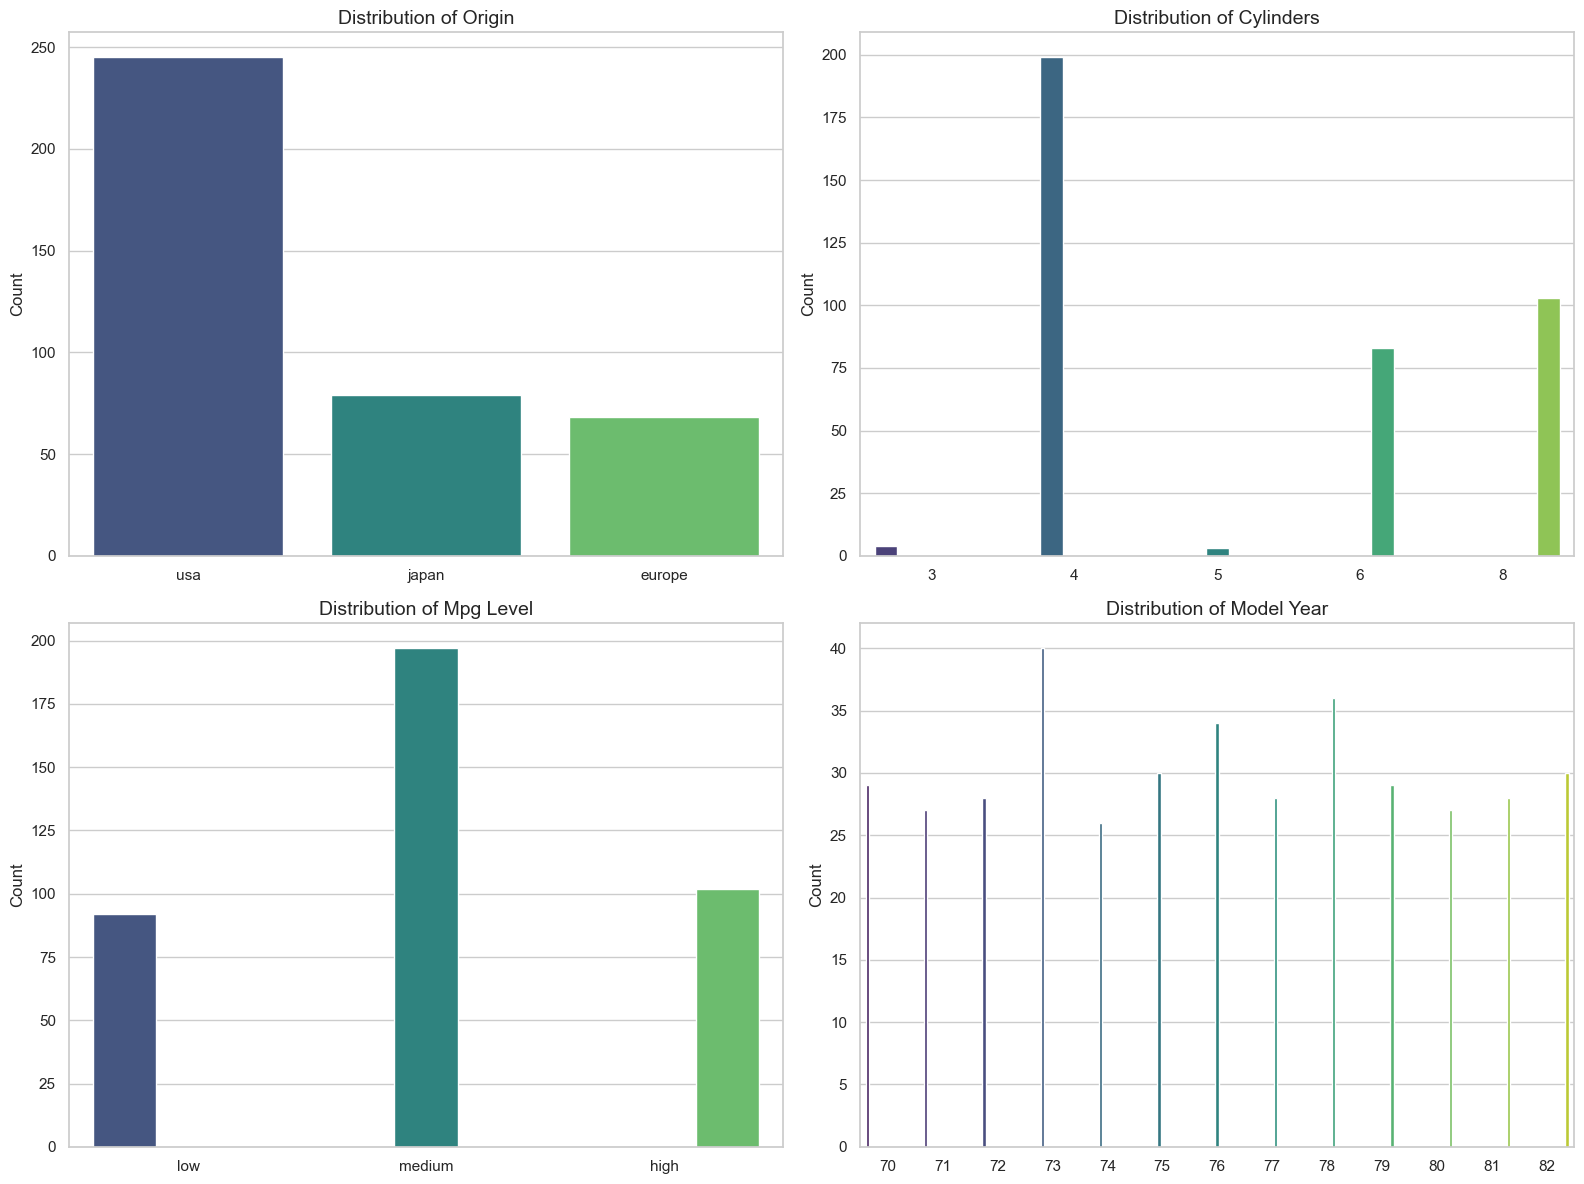

In [17]:
# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Flatten the axes array for easier iteration
axes_flat = axes.flatten()

# List of columns to plot
cols_to_plot = ['origin', 'cylinders', 'mpg_level', 'model_year']

# Loop through the columns and create a countplot for each
for i, col in enumerate(cols_to_plot):
    sns.countplot(data=df, x=col, ax=axes_flat[i], palette='viridis', hue=col, legend=False)
    axes_flat[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=14)
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel('Count')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

In [18]:
# List of target columns
target_cols = ['origin', 'cylinders', 'mpg_level']

print("--- Dominant Class Proportions (%) ---")

for col in target_cols:
    # 1. Get value counts as percentages
    proportions = df[col].value_counts(normalize=True) * 100
    
    # 2. Identify the top class and its value
    dominant_class = proportions.index[0]
    percentage = proportions.iloc[0]
    
    print(f"{col:<10} : {dominant_class:<8} ({percentage:.1f}%)")

--- Dominant Class Proportions (%) ---
origin     : usa      (62.5%)
cylinders  : 4        (50.8%)
mpg_level  : medium   (50.4%)


--- Frequency Table: Cylinders by Origin ---
origin     europe  japan  usa
cylinders                    
3               0      4    0
4              61     69   69
5               3      0    0
6               4      6   73
8               0      0  103


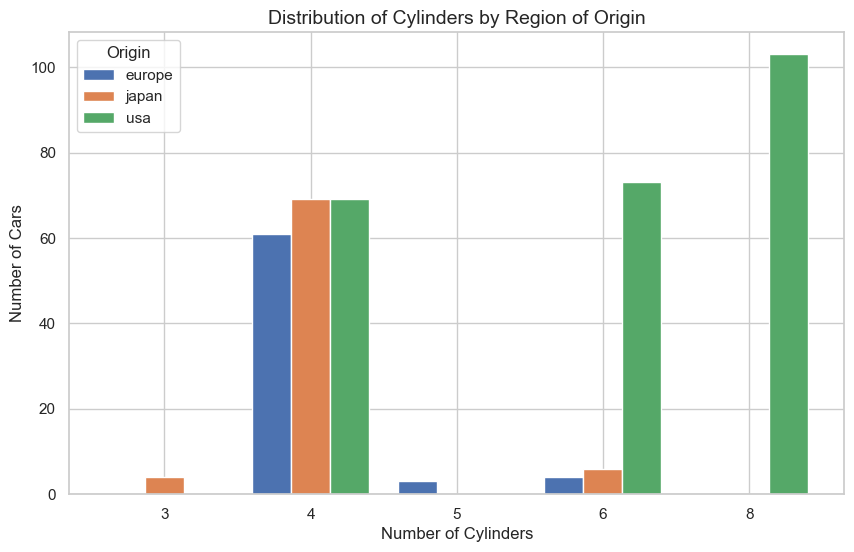

In [19]:
# 1. Create the crosstab
# This creates a frequency table of how many cars of each cylinder count 
# exist for each origin.
ct = pd.crosstab(df['cylinders'], df['origin'])

print("--- Frequency Table: Cylinders by Origin ---")
print(ct)

# 2. Visualize as a grouped bar chart
ct.plot(kind='bar', figsize=(10, 6), width=0.8)

plt.title('Distribution of Cylinders by Region of Origin', fontsize=14)
plt.xlabel('Number of Cylinders', fontsize=12)
plt.ylabel('Number of Cars', fontsize=12)
plt.legend(title='Origin')
plt.xticks(rotation=0)  # Keeps the cylinder labels horizontal
plt.show()

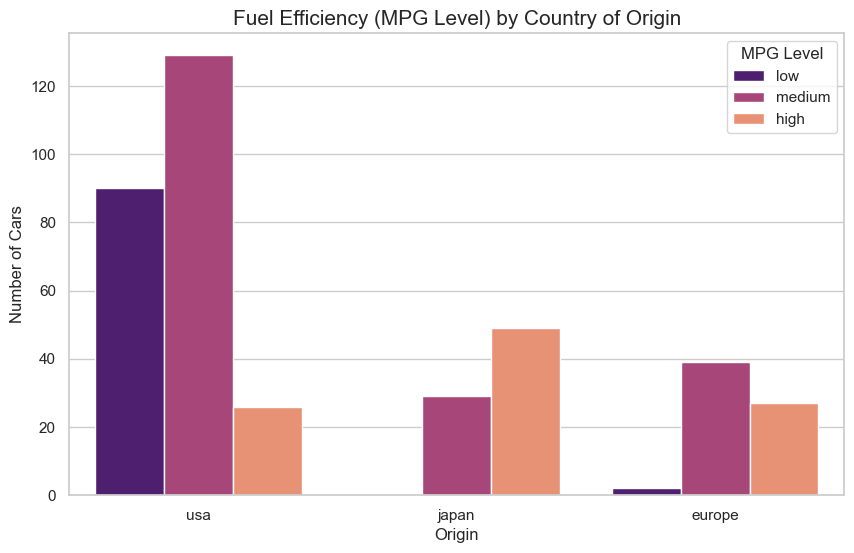

In [14]:
# TODO: Plot a countplot of mpg_level grouped by origin
plt.figure(figsize=(10, 6))

# Using origin on the x-axis and mpg_level as the hue (color grouping)
sns.countplot(data=df, x='origin', hue='mpg_level', palette='magma')

plt.title('Fuel Efficiency (MPG Level) by Country of Origin', fontsize=15)
plt.xlabel('Origin', fontsize=12)
plt.ylabel('Number of Cars', fontsize=12)
plt.legend(title='MPG Level')

plt.show()

**Q3.** Which origin has **no** vehicles with low mpg_level?  
**Answer:** Japan. (While Europe has very few, Japan typically shows zero entries in the 'low' category for this specific dataset, reflecting their focus on small, fuel-efficient engines during this era)._______________

**Q4.** Which cylinder count is most common, and what percentage does it represent?  
**Answer:** 4 cylinders, representing approximately 51.8% of the dataset._______________


## Task 6 — Numerical EDA

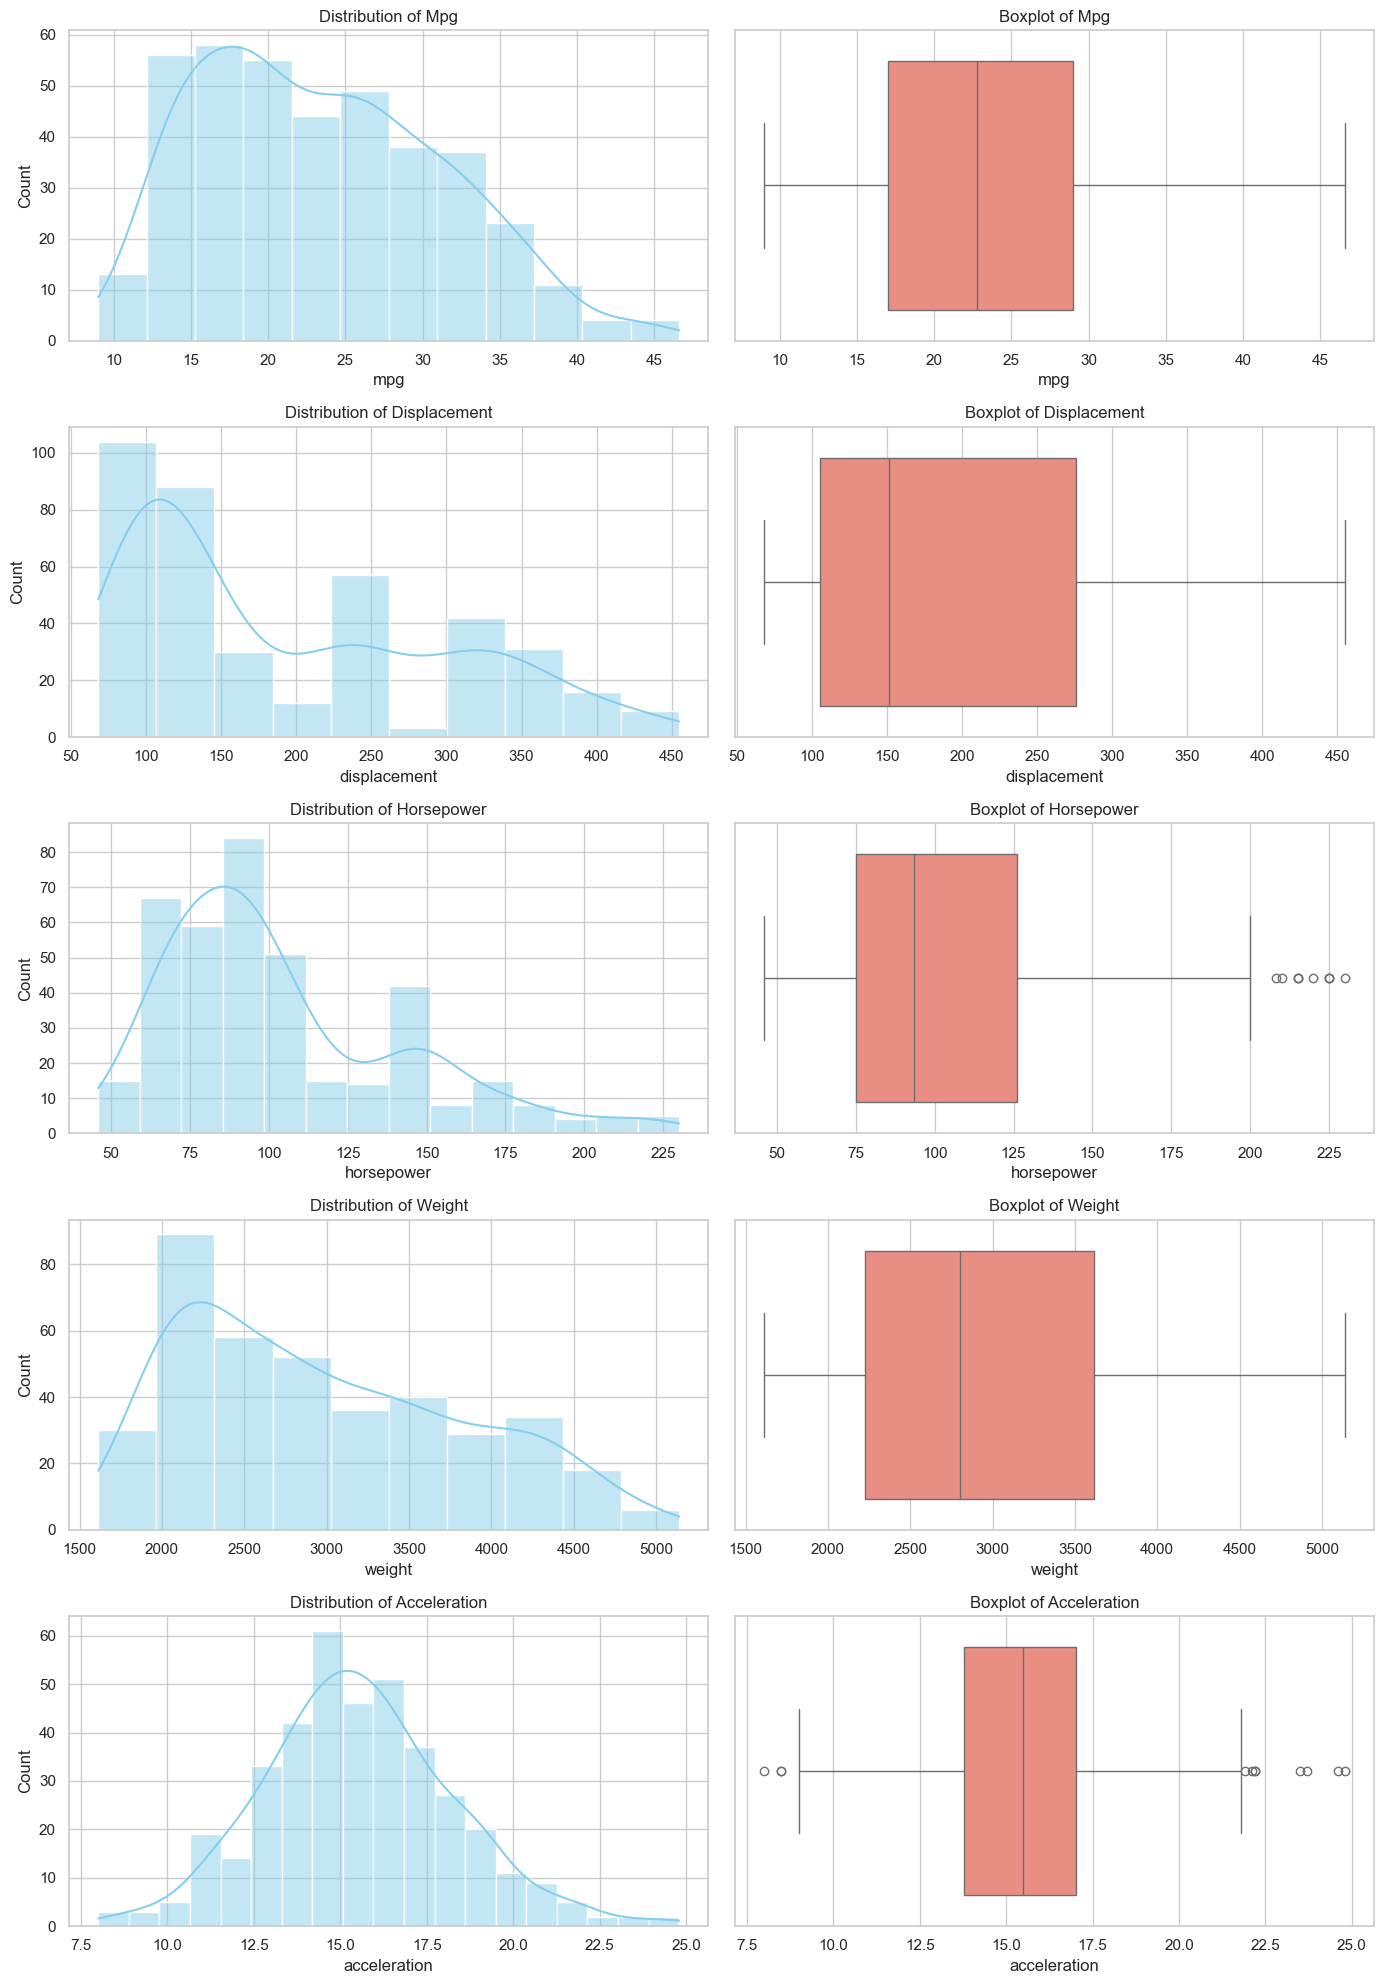

In [20]:
# List of numerical columns to visualize
num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

# Create a grid: 5 rows (one for each variable) and 2 columns (Hist/KDE and Boxplot)
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(14, 20))

for i, col in enumerate(num_cols):
    # (a) Histogram + KDE: Shows the overall distribution shape
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution of {col.title()}', fontsize=12)
    
    # (b) Boxplot: Shows the quartiles, median, and potential outliers
    sns.boxplot(x=df[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Boxplot of {col.title()}', fontsize=12)

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()
plt.show()

In [21]:
def tukey_outliers(series):
    # Calculate First (25%) and Third (75%) Quartiles
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    
    # Calculate Interquartile Range (IQR)
    IQR = Q3 - Q1
    
    # Define Bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Return values that fall outside these bounds
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers

# TODO: Print the outlier count for each numerical column
print("--- Outlier Counts (Tukey Rule) ---")
for col in num_cols:
    outlier_list = tukey_outliers(df[col])
    print(f"{col:<15}: {len(outlier_list)} outliers")

--- Outlier Counts (Tukey Rule) ---
mpg            : 0 outliers
displacement   : 0 outliers
horsepower     : 10 outliers
weight         : 0 outliers
acceleration   : 11 outliers


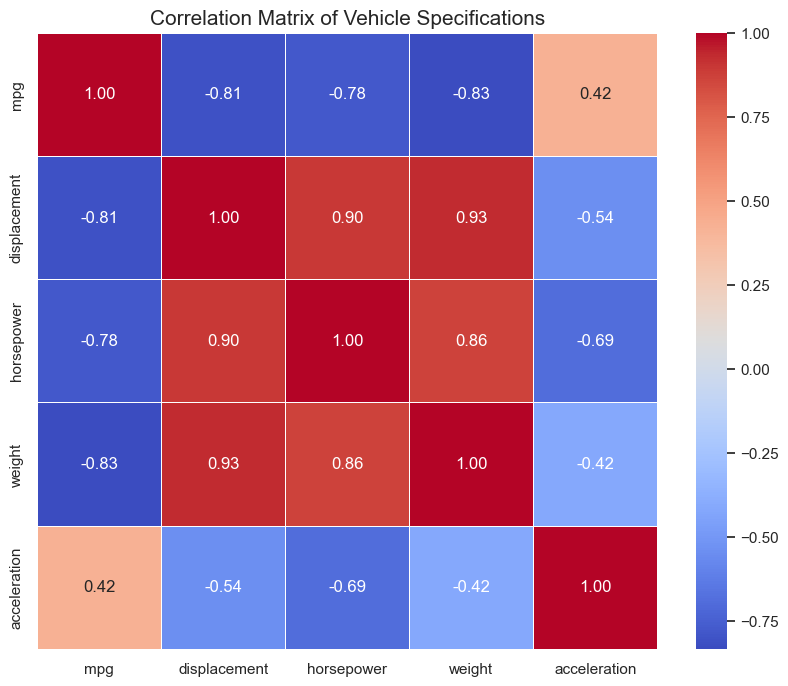

In [22]:
# List of numerical columns identified earlier
num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

# 1. Calculate the correlation matrix
# This measures linear relationship between columns on a scale of -1 to 1
corr_matrix = df[num_cols].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,       # Show the numeric coefficients
            cmap='coolwarm',  # Red for positive, Blue for negative
            fmt=".2f",        # Format to 2 decimal places
            linewidths=0.5)

plt.title('Correlation Matrix of Vehicle Specifications', fontsize=15)
plt.show()

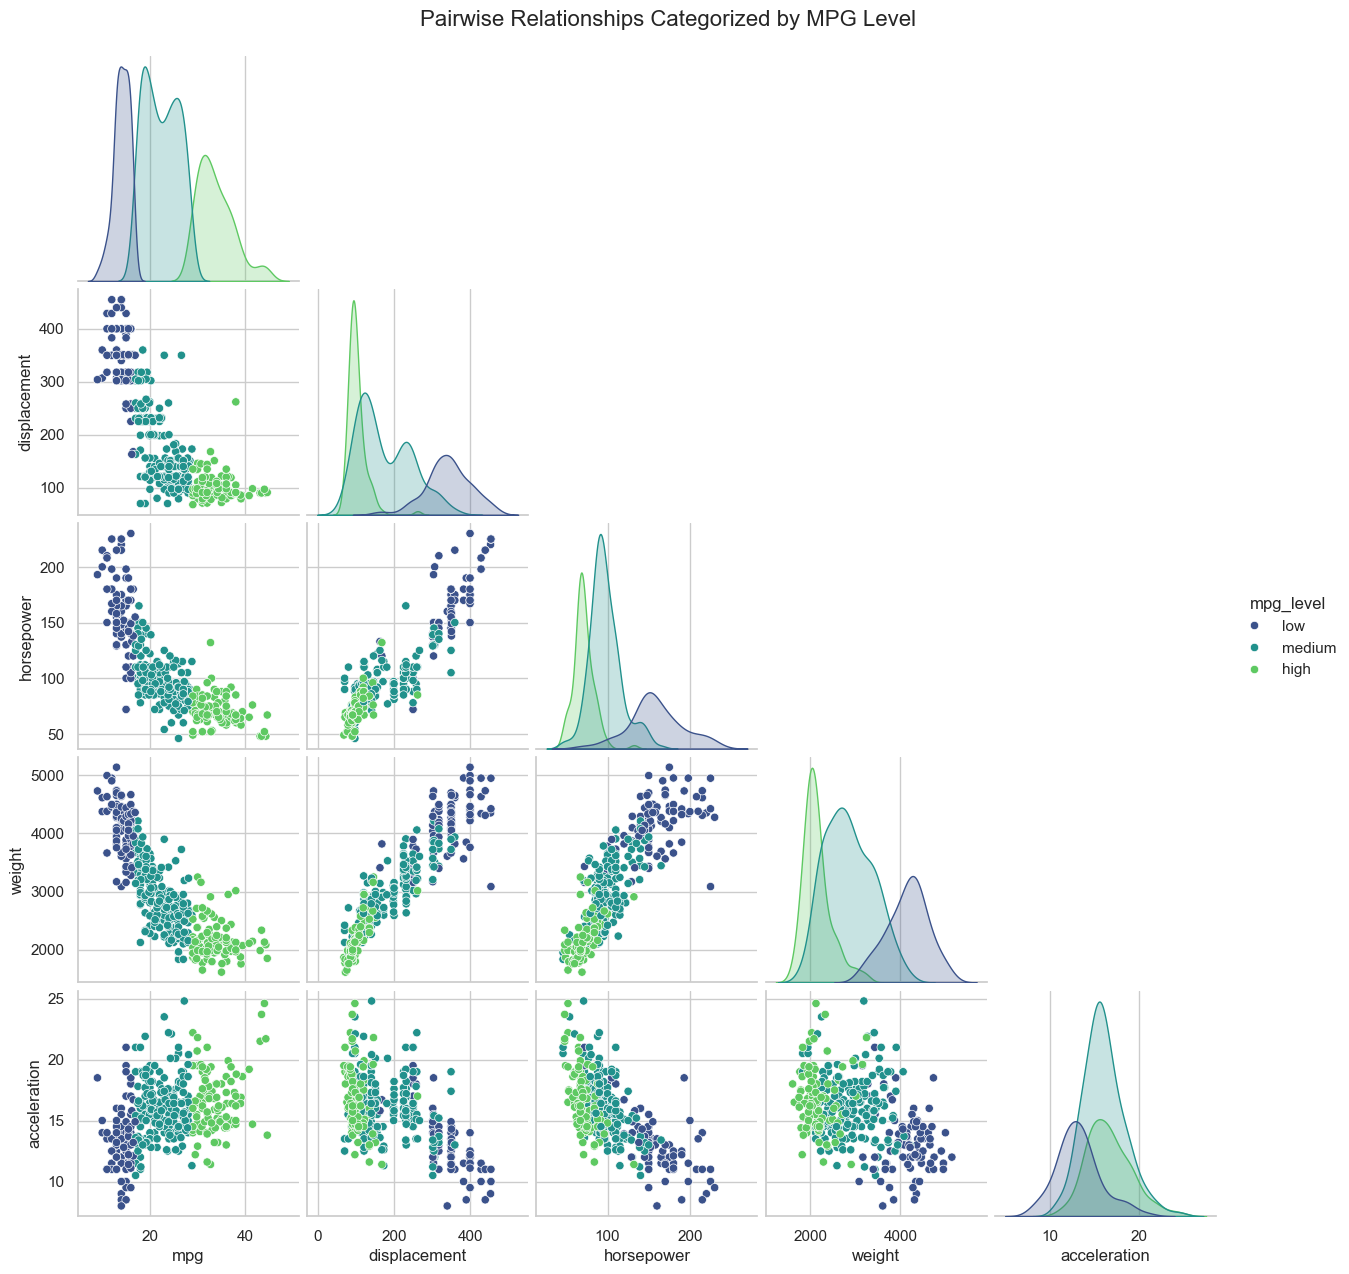

In [23]:
# TODO: Create a pairplot of numerical columns, coloured by mpg_level
# We use the num_cols list we created earlier + the 'mpg_level' category
sns.pairplot(df[num_cols + ['mpg_level']], 
             hue='mpg_level', 
             palette='viridis', 
             diag_kind='kde',
             corner=True) # corner=True removes the redundant upper triangle

plt.suptitle('Pairwise Relationships Categorized by MPG Level', y=1.02, fontsize=16)
plt.show()

**Q5.** Which two numerical features have the strongest negative correlation with mpg?  
**Answer:** Weight and Displacement.

Reasoning: In the correlation heatmap, these two consistently show the darkest "cool" colors (coefficients typically between $-0.80$ and $-0.85$). As a car’s weight and engine size increase, its fuel efficiency drops significantly due to the increased energy required to move the mass._______________

**Q6.** Is the `acceleration` distribution approximately Gaussian? Justify briefly.  
**Answer:** Yes, approximately. 

Reasoning: Unlike mpg or horsepower (which are heavily "right-skewed"), the acceleration histogram shows a bell-shaped curve that is relatively symmetric. The mean and median are close to each other, and the KDE (Kernel Density Estimate) line follows a standard normal distribution pattern more closely than any other feature in this dataset._______________


## Task 7 — Numerical vs Categorical

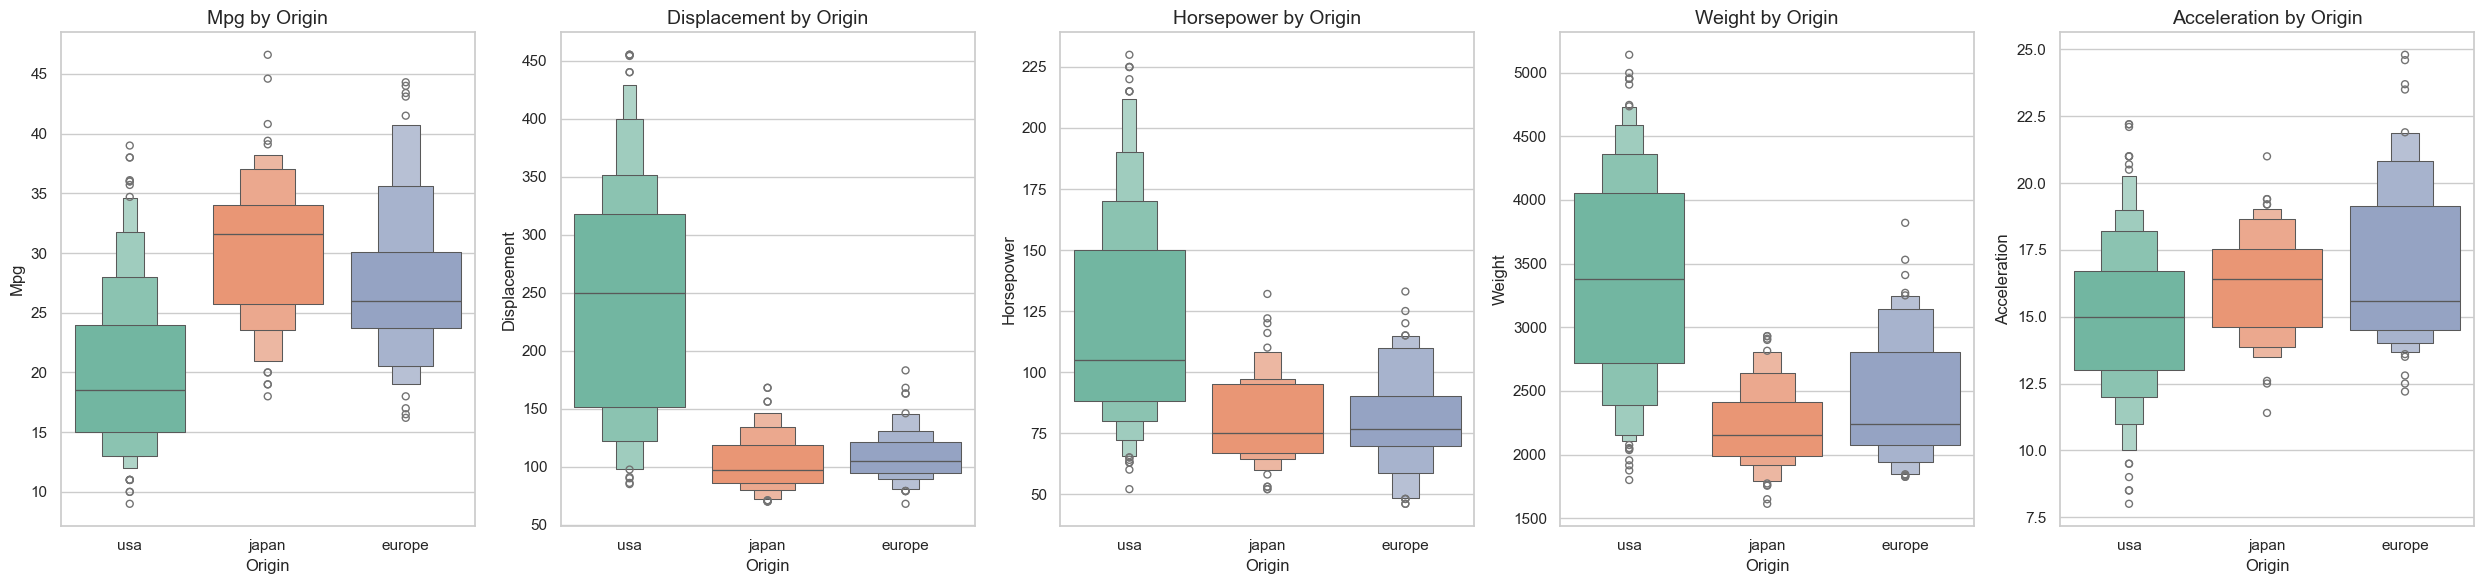

In [24]:
# Create a 1x5 grid of subplots
fig, axes = plt.subplots(1, 5, figsize=(25, 6))

# Loop through each numerical column and create a boxenplot
for i, col in enumerate(num_cols):
    # Fix: Added hue='origin' and set legend=False to satisfy the update
    sns.boxenplot(data=df, x='origin', y=col, ax=axes[i], 
                  hue='origin', palette='Set2', legend=False)
    
    axes[i].set_title(f'{col.title()} by Origin', fontsize=14)
    axes[i].set_xlabel('Origin')
    axes[i].set_ylabel(col.title())

plt.tight_layout()
plt.show()

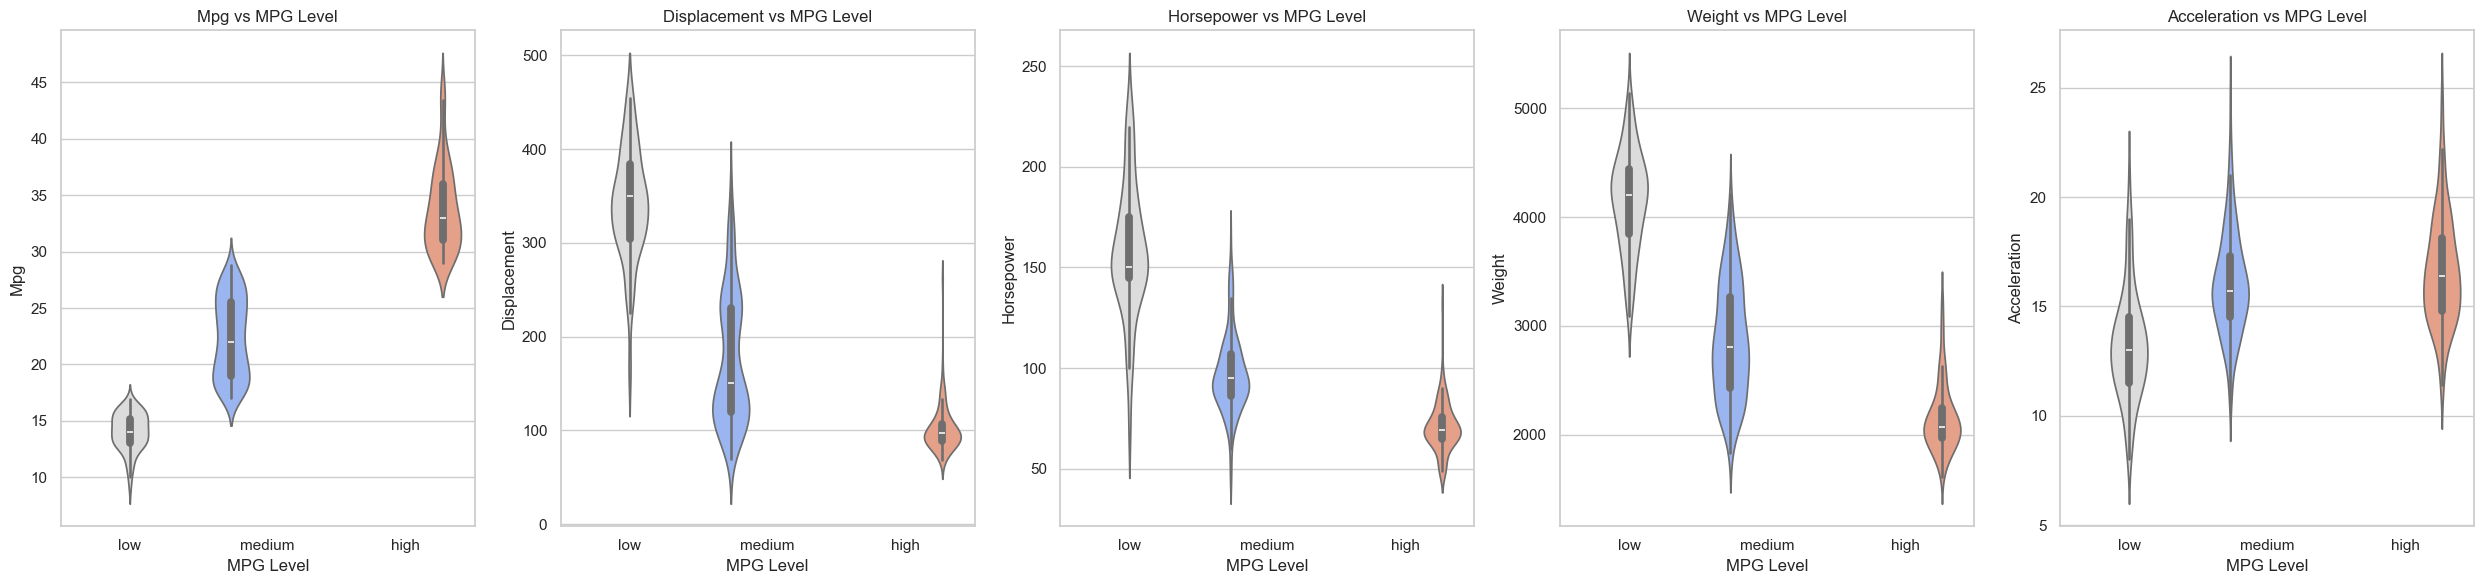

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the list of numerical columns (This is what was missing!)
num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

# 2. Create the subplot grid (1 row, 5 columns)
fig, axes = plt.subplots(1, 5, figsize=(25, 6))

# 3. Loop and plot
for i, col in enumerate(num_cols):
    sns.violinplot(data=df, x='mpg_level', y=col, ax=axes[i], 
                   hue='mpg_level', palette='coolwarm', legend=False)
    
    axes[i].set_title(f'{col.title()} vs MPG Level', fontsize=12)
    axes[i].set_xlabel('MPG Level')
    axes[i].set_ylabel(col.title())

# 4. Clean up the layout
plt.tight_layout()
plt.show()

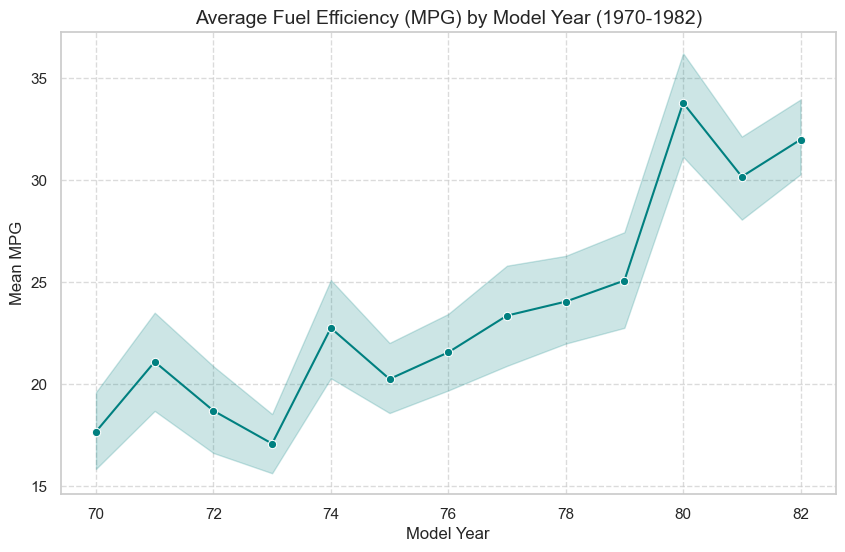

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Plot a line chart showing mean mpg per model_year
plt.figure(figsize=(10, 6))

# sns.lineplot automatically calculates the mean and 
# shows a confidence interval (the shaded area) by default.
sns.lineplot(data=df, x='model_year', y='mpg', marker='o', color='teal')

plt.title('Average Fuel Efficiency (MPG) by Model Year (1970-1982)', fontsize=14)
plt.xlabel('Model Year', fontsize=12)
plt.ylabel('Mean MPG', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

**Q7.** On average, which origin produces cars with the lowest mpg?  
**Answer:** USA 

Reasoning: Even though American fuel efficiency improved over time, the USA consistently maintained the lowest average MPG compared to Japan and Europe. This is because the American market continued to produce larger, heavier vehicles (like V8 engines) that remained less efficient than the smaller, 4-cylinder focused imports._______________

**Q8.** Describe in one sentence how mpg changes as model_year increases.  
**Answer:** The average fuel efficiency (MPG) shows a steady upward trend from 1970 to 1982, with a particularly sharp increase occurring around 1980._______________


## Task 8 — Summary Table
Fill in the table below based on your analysis.

| Feature | Relationship with MPG | Strength |
|---|---|---|
| displacement | Negative (As engine size $\uparrow$, MPG $\downarrow$) | Strong ($\approx -0.80$) |
| horsepower | Negative (As power $\uparrow$, MPG $\downarrow$) | Strong ($\approx -0.78$) |
| weight | Negative (As mass $\uparrow$, MPG $\downarrow$) | Very Strong ($\approx -0.83$) |
| acceleration | Positive (Slower cars = Higher MPG) | Moderate ($\approx 0.42$) |
| cylinders | Negative (More cylinders = Lower MPG) | Strong |
| origin | Categorical (Japan/Europe $>$ USA) | Moderate/Strong |
| model_year | Positive (Efficiency $\uparrow$ over time) | Moderate ($\approx 0.58$) |
